# PFA v3 — Corn mensuel × GISS (ceinture) + SPEI (USA)

**Objectif :** relier les **rendements mensuels** du maïs CBOT (`ZC=F`) aux **anomalies de température** NASA GISS (boîte ceinture du maïs) et à un indice **SPEI** agrégé **États-Unis** (`spei_usa.csv`) — sécheresse / humidité relative au climat.

- Fichiers : `corn_monthly_returns.csv`, `gistemp250_GHCNv4.csv`, `spei_usa.csv` dans `dataSets/v3/`  
- GISS : lecture par **chunks**.  
- Lancer depuis **`MLStudy2`**.

## 0. Imports et zone géographique

**Boîte « core Corn Belt »** (documentée dans le rapport) :
- latitude **37°N–45°N**
- longitude **−100°–−87°** (convention −180…180, comme dans le fichier GISS)

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
)

BASE = Path.cwd()
CORN_PATH = BASE / "dataSets" / "v3" / "corn_monthly_returns.csv"
GISS_PATH = BASE / "dataSets" / "v3" / "gistemp250_GHCNv4.csv"
SPEI_PATH = BASE / "dataSets" / "v3" / "spei_usa.csv"

CHUNKSIZE = 1_000_000
LAT_MIN, LAT_MAX = 37.0, 45.0
LON_MIN, LON_MAX = -100.0, -87.0

assert CORN_PATH.exists(), f"Manquant : {CORN_PATH} — placez-vous dans MLStudy2"
assert GISS_PATH.exists(), f"Manquant : {GISS_PATH}"
assert SPEI_PATH.exists(), f"Manquant : {SPEI_PATH}"

## 1. Rendements mensuels du maïs

Yahoo export : la **2ᵉ ligne** contient le symbole `ZC=F`, on l’ignore.  
On normalise chaque date en **début de mois** (`Month`) pour joindre avec la colonne `time` du GISS (`YYYY-MM`).

In [18]:
corn = pd.read_csv(CORN_PATH, skiprows=[1])
corn["Date"] = pd.to_datetime(corn["Date"], errors="coerce")
corn = corn.dropna(subset=["Date"])
corn["Month"] = corn["Date"].dt.to_period("M").dt.to_timestamp()
corn = corn[["Month", "Close", "Monthly_Return"]].sort_values("Month").reset_index(drop=True)
corn["Target_up"] = (corn["Monthly_Return"] > 0).astype(int)
print(corn.head())
print("…")
print(corn.tail())
print("n =", len(corn))

       Month  Close  Monthly_Return  Target_up
0 2000-08-01  182.0        0.009709          1
1 2000-09-01  192.0        0.054945          1
2 2000-10-01  196.0        0.020833          1
3 2000-11-01  205.0        0.045918          1
4 2000-12-01  222.5        0.085366          1
…
         Month   Close  Monthly_Return  Target_up
304 2025-12-01  440.25        0.010907          1
305 2026-01-01  428.25       -0.027257          0
306 2026-02-01  438.75        0.024518          1
307 2026-03-01  457.75        0.043305          1
308 2026-04-01  452.00       -0.012561          0
n = 309


## 2. GISS — moyenne mensuelle sur la ceinture du maïs

Pour chaque `time` :
1. garder les points dont `(lat, lon)` est dans la boîte ;
2. supprimer les `tempanomaly_degC` manquants ;
3. **moyenne arithmétique** sur les mailles restantes → une série **anomalie en °C** (pas la température absolue).

Les chunks sont agrégés avec `sum` et `count`, puis `mean = sum / count` globalement sur tous les chunks.

In [19]:
def corn_belt_monthly_series(csv_path: Path, chunksize: int) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        chunk = chunk.dropna(subset=["tempanomaly_degC", "time"])
        if chunk.empty:
            continue
        sel = chunk[
            (chunk["lat"] >= LAT_MIN)
            & (chunk["lat"] <= LAT_MAX)
            & (chunk["lon"] >= LON_MIN)
            & (chunk["lon"] <= LON_MAX)
        ]
        if sel.empty:
            continue
        parts.append(
            sel.groupby("time", sort=False)["tempanomaly_degC"].agg(["sum", "count"])
        )
    if not parts:
        return pd.DataFrame(columns=["Month", "temp_belt_mean"])
    agg = pd.concat(parts).groupby(level=0).sum()
    belt_mean = agg["sum"] / agg["count"]
    out = belt_mean.rename("temp_belt_mean").reset_index()
    out["Month"] = pd.to_datetime(
        out["time"].astype(str).str.strip() + "-01", errors="coerce"
    )
    return out.drop(columns=["time"]).dropna(subset=["Month"])


giss_monthly = corn_belt_monthly_series(GISS_PATH, CHUNKSIZE)
print(giss_monthly.head())
print("…")
print(giss_monthly.tail())
print("n =", len(giss_monthly))

   temp_belt_mean      Month
0        7.740000 1880-01-01
1        2.387429 1880-02-01
2       -0.173143 1880-03-01
3       -0.028286 1880-04-01
4        3.181428 1880-05-01
…
      temp_belt_mean      Month
1749        2.546286 2025-10-01
1750        2.140000 2025-11-01
1751        1.077143 2025-12-01
1752        1.202571 2026-01-01
1753        4.572286 2026-02-01
n = 1754


## 3. Fusion (inner join)

Enchaînement : **corn** × **GISS** × **SPEI** sur `Month`. Seuls les mois présents **partout** sont conservés.

In [20]:
spei = pd.read_csv(SPEI_PATH)
spei["Month"] = pd.to_datetime(spei["time"], errors="coerce").dt.to_period("M").dt.to_timestamp()
spei = spei[["Month", "spei"]].dropna(subset=["Month"]).drop_duplicates(subset=["Month"], keep="last")

df = corn.merge(giss_monthly, on="Month", how="inner").merge(spei, on="Month", how="inner")
print("Shape :", df.shape)
print("De", df["Month"].min().date(), "à", df["Month"].max().date())
df.head(10)

Shape : (304, 6)
De 2000-08-01 à 2025-11-01


,Month,Close,Monthly_Return,Target_up,temp_belt_mean,spei
0,2000-08-01,182.00,0.009709,1,1.389429,-0.417125
1,2000-09-01,192.00,0.054945,1,0.699143,-0.252058
2,2000-10-01,196.00,0.020833,1,1.588286,0.063593
3,2000-11-01,205.00,0.045918,1,-1.900571,0.447560
4,2000-12-01,222.50,0.085366,1,-6.125714,-0.194191
5,2001-01-01,208.50,-0.062921,0,2.228000,-0.141174
6,2001-02-01,211.25,0.013189,1,-0.944286,0.270554
7,2001-03-01,206.50,-0.022485,0,-0.893714,-0.064330
8,2001-04-01,195.00,-0.055690,0,2.278000,-0.224323
9,2001-05-01,190.25,-0.024359,0,0.935714,-0.477605


### Fusion — prix maïs et anomalie GISS (double échelle)

Même idée que le notebook **S&P × GISS** : **clôture du maïs** (échelle de gauche) et **anomalie de température** sur la ceinture du maïs (échelle de droite), sur la **période commune** après fusion des séries.

In [ ]:
fig, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(df["Month"], df["Close"], color="#1f77b4", lw=0.8, label="Clôture maïs (ZC=F)")
ax_r.plot(
    df["Month"],
    df["temp_belt_mean"],
    color="#d62728",
    lw=0.8,
    alpha=0.9,
    label="Anomalie GISS ceinture (°C)",
)
ax_l.set_xlabel("Mois")
ax_l.set_ylabel("Clôture ($)", color="#1f77b4")
ax_r.set_ylabel("Anomalie temp. ceinture (°C)", color="#d62728")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#d62728")
ax_l.set_title("Maïs CBOT × anomalie GISS (ceinture) — période commune")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper left", fontsize=8)
ax_l.grid(True, alpha=0.3)
plt.show()

## 4. EDA — séries et dispersion

Corrélation **mensuelle** souvent faible (marché global). Le **SPEI** complète la température (humidité / sécheresse vs climat) mais reste **USA agrégé**, pas la ceinture du maïs seule.

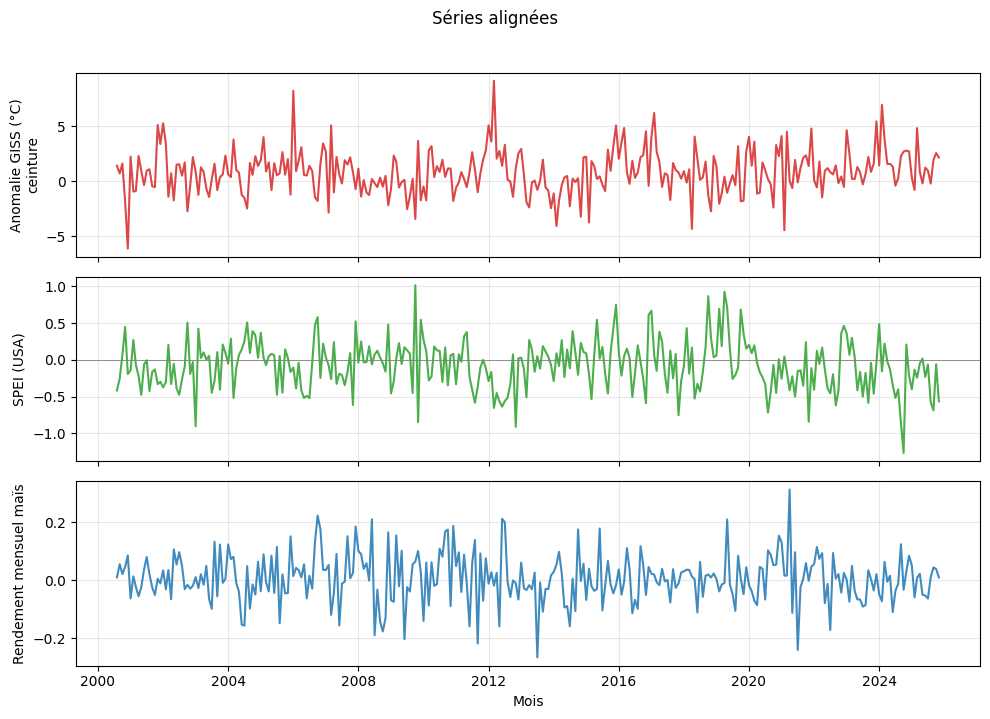

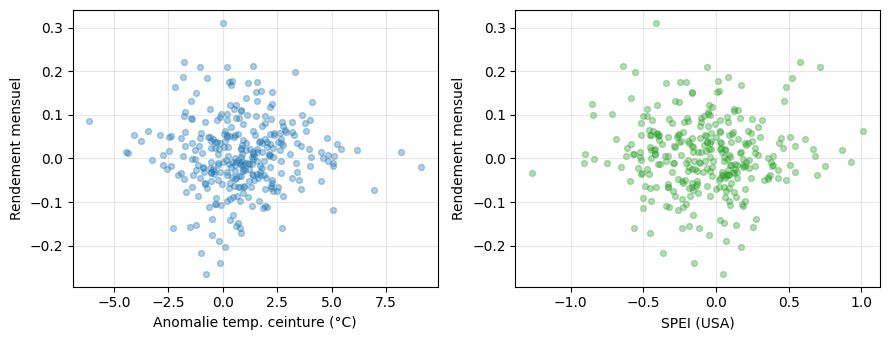

Corrélation Pearson (anomalie temp., rendement) = -0.0007
Corrélation Pearson (SPEI, rendement) = -0.0115
Corrélation (anomalie temp., SPEI) = -0.2912


In [21]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(df["Month"], df["temp_belt_mean"], color="tab:red", alpha=0.85)
axes[0].set_ylabel("Anomalie GISS (°C)\nceinture")
axes[0].grid(True, alpha=0.3)
axes[1].plot(df["Month"], df["spei"], color="tab:green", alpha=0.85)
axes[1].set_ylabel("SPEI (USA)")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].grid(True, alpha=0.3)
axes[2].plot(df["Month"], df["Monthly_Return"], color="tab:blue", alpha=0.85)
axes[2].set_ylabel("Rendement mensuel maïs")
axes[2].set_xlabel("Mois")
axes[2].grid(True, alpha=0.3)
fig.suptitle("Séries alignées", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].scatter(df["temp_belt_mean"], df["Monthly_Return"], alpha=0.35, s=18)
ax[0].set_xlabel("Anomalie temp. ceinture (°C)")
ax[0].set_ylabel("Rendement mensuel")
ax[0].grid(True, alpha=0.3)
ax[1].scatter(df["spei"], df["Monthly_Return"], alpha=0.35, s=18, color="tab:green")
ax[1].set_xlabel("SPEI (USA)")
ax[1].set_ylabel("Rendement mensuel")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r_t = df["temp_belt_mean"].corr(df["Monthly_Return"])
r_s = df["spei"].corr(df["Monthly_Return"])
r_ts = df["temp_belt_mean"].corr(df["spei"])
print(f"Corrélation Pearson (anomalie temp., rendement) = {r_t:.4f}")
print(f"Corrélation Pearson (SPEI, rendement) = {r_s:.4f}")
print(f"Corrélation (anomalie temp., SPEI) = {r_ts:.4f}")

## 5. Modèles simples — découpage chronologique

**Features :** `temp_l1`, `temp_l2`, `spei_l1`, `spei_l2` (rien du mois courant).  
**Découpage :** **80 %** des mois en train puis test chronologique.

- **Régression** / **classification** comme avant, avec baseline implicite (signal souvent faible).

In [22]:
m = df.copy()
m["temp_l1"] = m["temp_belt_mean"].shift(1)
m["temp_l2"] = m["temp_belt_mean"].shift(2)
m["spei_l1"] = m["spei"].shift(1)
m["spei_l2"] = m["spei"].shift(2)
m = m.dropna().reset_index(drop=True)

feat_cols = ["temp_l1", "temp_l2", "spei_l1", "spei_l2"]
X = m[feat_cols]
y_ret = m["Monthly_Return"]
y_up = m["Target_up"]

split = int(len(m) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
yret_train, yret_test = y_ret.iloc[:split], y_ret.iloc[split:]
yup_train, yup_test = y_up.iloc[:split], y_up.iloc[split:]

print(f"Train : {len(X_train)} mois | Test : {len(X_test)} mois")
print(f"Période test : {m['Month'].iloc[split].date()} → {m['Month'].iloc[-1].date()}")

reg = LinearRegression()
reg.fit(X_train, yret_train)
pred_ret = reg.predict(X_test)
print("\n--- Régression (rendement) ---")
print(f"R² test : {r2_score(yret_test, pred_ret):.4f}")
print(f"MAE test : {mean_absolute_error(yret_test, pred_ret):.6f}")
print(f"Coefficients : {dict(zip(feat_cols, reg.coef_))}")

clf = LogisticRegression(max_iter=500)
clf.fit(X_train, yup_train)
pred_up = clf.predict(X_test)
print("\n--- Classification (mois > 0) ---")
print(f"Accuracy test : {accuracy_score(yup_test, pred_up):.4f}")
print(f"F1 (classe 1) test : {f1_score(yup_test, pred_up, zero_division=0):.4f}")
print(classification_report(yup_test, pred_up, digits=3))

Train : 241 mois | Test : 61 mois
Période test : 2020-11-01 → 2025-11-01

--- Régression (rendement) ---
R² test : 0.0461
MAE test : 0.059085
Coefficients : {'temp_l1': np.float64(0.004153110398444054), 'temp_l2': np.float64(-0.0025976457050223586), 'spei_l1': np.float64(0.03099619829435927), 'spei_l2': np.float64(-0.028518594844532057)}

--- Classification (mois > 0) ---
Accuracy test : 0.5738
F1 (classe 1) test : 0.5938
              precision    recall  f1-score   support

           0      0.500     0.615     0.552        26
           1      0.655     0.543     0.594        35

    accuracy                          0.574        61
   macro avg      0.578     0.579     0.573        61
weighted avg      0.589     0.574     0.576        61



### Graphique — baseline (GISS seul) vs modèle enrichi (+ SPEI)

Même **découpe chronologique** que la section 5 (**80 %** train / **20 %** test). **Précision** et **F1** (classe « hausse »). **Baseline** : lags d’**anomalie GISS** uniquement ; **enrichi** : lags GISS **+** lags **SPEI (USA)**. La **ligne pointillée** : prédire **toujours un mois positif** sur le test.

Modèles : **régression logistique** et **forêt aléatoire** (alignés sur `PFA_pipeline.ipynb`).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    _ = m.shape
    _ = split
except NameError as e:
    raise RuntimeError(
        "Exécuter d'abord la cellule qui construit m, les lags et split (section 5)."
    ) from e

feat_temp = ["temp_l1", "temp_l2"]
feat_all = ["temp_l1", "temp_l2", "spei_l1", "spei_l2"]
X_tr_m = m[feat_temp].iloc[:split]
X_te_m = m[feat_temp].iloc[split:]
X_tr_a = m[feat_all].iloc[:split]
X_te_a = m[feat_all].iloc[split:]
y_tr = m["Target_up"].iloc[:split]
y_te = m["Target_up"].iloc[split:]


def make_lr():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def _test_scores(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    return acc, f1


model_specs = [
    ("Régression logistique", make_lr),
    ("Forêt aléatoire", make_rf),
]
acc_base, acc_enr, f1_base, f1_enr = [], [], [], []
for _label, factory in model_specs:
    ab, fb = _test_scores(factory(), X_tr_m, X_te_m, y_tr, y_te)
    ae, fe = _test_scores(factory(), X_tr_a, X_te_a, y_tr, y_te)
    acc_base.append(ab)
    acc_enr.append(ae)
    f1_base.append(fb)
    f1_enr.append(fe)

x = np.arange(len(model_specs))
width = 0.35
p_up_test = float(y_te.mean())
acc_naive_up = p_up_test
f1_naive_up = (2 * p_up_test / (1 + p_up_test)) if p_up_test > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
configs = [
    (acc_base, acc_enr, "Précision (accuracy)", acc_naive_up, "Toujours « hausse » (acc.)"),
    (f1_base, f1_enr, "F1 (classe hausse)", f1_naive_up, "Toujours « hausse » (F1 naïf)"),
]
for ax, (base, enr, title, ref_line, ref_label) in zip(axes, configs):
    ax.bar(x - width / 2, base, width, label="Baseline (lags GISS)", color="#4C72B0")
    ax.bar(x + width / 2, enr, width, label="Enrichi (+ lags SPEI)", color="#55A868")
    ax.axhline(ref_line, color="gray", linestyle="--", linewidth=1.2, label=ref_label)
    ax.set_xticks(x)
    ax.set_xticklabels([m_[0].replace(" ", "\n") for m_ in model_specs], fontsize=9)
    ax.set_ylabel(title)
    top = max(ref_line, *base, *enr)
    ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Maïs CBOT × GISS ceinture + SPEI USA — test chronologique : GISS vs GISS + SPEI",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 6. Limites (à reprendre dans le rapport)

1. **GISS** : anomalie, grille **~2°** ; **SPEI** : indice **USA agrégé** (pas Corn Belt seul) — documenter source / échelle temporelle du SPEI dans le mémoire.  
2. **Boîte lat/lon** : approximation ; **corrélation partielle** temp / SPEI possible.  
3. **Association ≠ causalité** ; marché anticipant.  
4. **POC** : pas un modèle de trading.

---
*v3 — corn × GISS ceinture + SPEI USA*

## 7. Méthode simple — saison de croissance, année, baselines

Données : **corn + GISS + SPEI** (déjà dans `df`).

1. Mois **mai–septembre** : stats sur `temp_belt_mean` **et** moyenne du **SPEI** sur la même fenêtre (`spei_gs_mean`).
2. **Rendement annuel** : $\prod_m (1 + r_m) - 1$ (années avec **≥ 10** mois).
3. **Lags** : signaux **Y−1** → rendement **Y** ; baselines comme en §5.
4. **Test** : **80 % / 20 %** des années.

*Peu d’années en test.*

Années (panel) : 2002 → 2025 | n = 24
Train / test : 19 / 5 | années test : [2021, 2022, 2023, 2024, 2025]

EDA : corrélation (gs_mean, ret_ann même année) = 0.2188 (biaisée, pour illustration)

--- Régression rendement annuel ---
R² test (modèle) : -0.2484
R² test (baseline = moyenne train) : -0.1735
MAE test (modèle) : 0.183288
MAE test (baseline) : 0.165165
Coefficients : {'gs_mean_l1': np.float64(-0.050787482624954555), 'gs_std_l1': np.float64(-0.8896172155466622), 'gs_range_l1': np.float64(0.3591803757619761), 'spei_gs_mean_l1': np.float64(0.05139996323158149)}

--- Classification année > 0 ---
Accuracy test (modèle) : 0.4000
Accuracy test (baseline majoritaire=1) : 0.4000
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         3
           1      0.400     1.000     0.571         2

    accuracy                          0.400         5
   macro avg      0.200     0.500     0.286         5
weighted avg      0.160     0.400     0.2

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

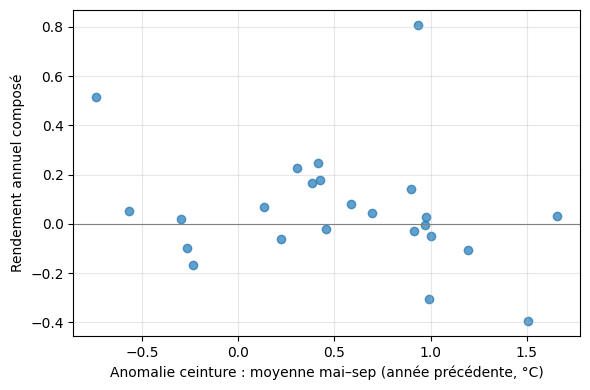

In [23]:
# --- 7. Saison de croissance → agrégats annuels ---

m = df.copy()
m["year"] = m["Month"].dt.year
m["mo"] = m["Month"].dt.month

# Années avec assez de mois (évite 2000 quasi vide)
ok_years = m.groupby("year").size()
ok_years = ok_years[ok_years >= 10].index
m = m[m["year"].isin(ok_years)]

gs = m[m["mo"].between(5, 9)]
yearly_w = gs.groupby("year").agg(
    gs_mean=("temp_belt_mean", "mean"),
    gs_std=("temp_belt_mean", "std"),
    gs_max=("temp_belt_mean", "max"),
    gs_min=("temp_belt_mean", "min"),
    spei_gs_mean=("spei", "mean"),
)
yearly_w["gs_range"] = yearly_w["gs_max"] - yearly_w["gs_min"]

yearly_r = (
    m.groupby("year")["Monthly_Return"]
    .apply(lambda s: float(np.prod(1.0 + s) - 1.0))
    .rename("ret_ann")
)

annual = yearly_w.join(yearly_r, how="inner").dropna().sort_index()
annual["ret_pos"] = (annual["ret_ann"] > 0).astype(int)

# Météo année (Y-1) → rendement année Y (lignes triées par année)
Ydf = annual.copy()
for col in ("gs_mean", "gs_std", "gs_range", "spei_gs_mean"):
    Ydf[f"{col}_l1"] = Ydf[col].shift(1)
Y = Ydf.dropna(
    subset=["gs_mean_l1", "gs_std_l1", "gs_range_l1", "spei_gs_mean_l1"]
)

feat = ["gs_mean_l1", "gs_std_l1", "gs_range_l1", "spei_gs_mean_l1"]
Xf = Y[feat]
yr = Y["ret_ann"]
ybin = Y["ret_pos"]

n = len(Y)
cut = int(n * 0.8)
X_tr, X_te = Xf.iloc[:cut], Xf.iloc[cut:]
yr_tr, yr_te = yr.iloc[:cut], yr.iloc[cut:]
yb_tr, yb_te = ybin.iloc[:cut], ybin.iloc[cut:]
years_te = Y.index[cut:]

print("Années (panel) :", Y.index.min(), "→", Y.index.max(), "| n =", n)
print("Train / test :", cut, "/", n - cut, "| années test :", list(years_te))

# Corrélation exploratoire (même année, sans lag — juste EDA)
r_gs = annual["gs_mean"].corr(annual["ret_ann"])
print(f"\nEDA : corrélation (gs_mean, ret_ann même année) = {r_gs:.4f} (biaisée, pour illustration)")

# --- Régression annuelle ---
reg_a = LinearRegression().fit(X_tr, yr_tr)
pred_a = reg_a.predict(X_te)
mean_train = yr_tr.mean()
base_pred = np.full_like(pred_a, fill_value=mean_train, dtype=float)

print("\n--- Régression rendement annuel ---")
print(f"R² test (modèle) : {r2_score(yr_te, pred_a):.4f}")
print(f"R² test (baseline = moyenne train) : {r2_score(yr_te, base_pred):.4f}")
print(f"MAE test (modèle) : {mean_absolute_error(yr_te, pred_a):.6f}")
print(f"MAE test (baseline) : {mean_absolute_error(yr_te, base_pred):.6f}")
print("Coefficients :", dict(zip(feat, reg_a.coef_)))

# --- Classification annuelle ---
maj = int(yb_tr.mode().iloc[0])
clf_a = LogisticRegression(max_iter=500).fit(X_tr, yb_tr)
pred_b = clf_a.predict(X_te)
base_cls = np.full(shape=len(yb_te), fill_value=maj, dtype=int)

print("\n--- Classification année > 0 ---")
print(f"Accuracy test (modèle) : {accuracy_score(yb_te, pred_b):.4f}")
print(f"Accuracy test (baseline majoritaire={maj}) : {accuracy_score(yb_te, base_cls):.4f}")
print(classification_report(yb_te, pred_b, digits=3))

# Visualisation rapide
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Y["gs_mean_l1"], Y["ret_ann"], alpha=0.7)
ax.set_xlabel("Anomalie ceinture : moyenne mai–sep (année précédente, °C)")
ax.set_ylabel("Rendement annuel composé")
ax.axhline(0, color="gray", lw=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()